# **ASTR 8060 (Observational Methods) SP26 Homework 6**
## Harrison Blake-Goszyk

-------

For the following tasks, document each step as best you can with text and by graphical representation in a Jupyter notebook. Turn in plots and quantitative notes, along with your reasoning for each step. Think of these as guidelines for assessing astronomical data, rather than an exact to-do list. Be creative and careful in your in-depth analysis of the data.
1. CCDs are ideal because over the available dynamic range, they are very linear (that is, one photon produces on electron).Test the linearity of the CCD using the sequence of exposures labeled linearity test in the log. Make a plot of ADU versus time and determine whether the chip is linear to the full 16 bits of the A-D converter. What you care about here is whether the signal stays linear with exposure time as the flux in the peak pixel approaches the 216 ADU limit.
2. Use photutils to perform aperture photometry on three (non saturated) stars in the PG1633+099 standard field: a really faint one, a medium bright one, and a bright one. Perform aperture photometry using at least 5 aperture sizes from very small to very large and make a plot that reproduces the one from Howell Figure 5.7 showing S/N as a function of aperture radius. What is a good aperture size to use for this dataset?
3. Identify the standard stars in the PG1633+099 frame from Landolt (1992).
4. Extract instrumental magnitudes for all of your standard stars using an approach that you’ve advocated for as best you can in the questions above.
5. Plot your standard star instrumental magnitudes versus their airmass (or since you have many different standard stars taken at different airmass, plot the difference between the accepted magnitude and your instrumental magnitude versus airmass). Use one of the linear fitting routines in Python to do a least squares fit to find and plot the extinction coefficients at each filter. You can find their magnitudes and colors in Landolt (1992).
6. After extinction correcting your standard stars to zero airmasses (i.e., you’re correcting to the top of the atmosphere), make a plot of the difference between real magnitudes and instrumental magnitudes using your standard stars as a function of V−R color and B−V color. Fit a linear relation to this trend. The fit gives you your instrumental zero points and the first order color term which let you transform your instrumental photometry to the standard system. Tabulate the instrumental zero point and first order color terms for each band in a neat, digestible way.
7. Using the extinction terms and color terms derived for the imaging dataset previously, do photometry on the stars in NGC6823 and make a color magnitude diagram of this open cluster. Either V vs. B−V or R vs. R−I are the most common ones you might find, but there may be others in the literature and you are welcome to follow their lead.

In [3]:
# Imaging director for extraction of files!
# CHANGE TO THE RIGHT DIRECTORY WHERE YOU IMAGES ARE!!!
data_dir = '/Users/blakeghg/Documents/Work/Courses!/Observational_Methods/Imaging/'
reduced_dir = '/Users/blakeghg/Documents/Work/Courses!/Observational_Methods/Imaging/reduced/'

----

# Problem 1:

"CCDs are ideal because over the available dynamic range, they are very linear (that is, one photon produces on electron).Test the linearity of the CCD using the sequence of exposures labeled linearity test in the log. Make a plot of ADU versus time and determine whether the chip is linear to the full 16 bits of the A-D converter. What you care about here is whether the signal stays linear with exposure time as the flux in the peak pixel approaches the 216 ADU limit."

Okay!! Firstly, let's glob.glob all the files that are labelled linearity test in the log (a074-80):

In [4]:
import glob
from astropy.io import fits

img_files_lintest = glob.glob(data_dir + 'a07[4-9]*.fits') + glob.glob(data_dir + 'a080.fits')

Now, we need to plot the exposure times of these images (2, 4, 8, 16, 32, 64, 128) w.r.t their ADUs, and see if the correlation is linear. I am going to calculate the total sum of the ADUs for each image without removing the overscan regions just yet, since we'll still get a linear correlation with them in. Here we go!

In [5]:
from ccdproc import subtract_overscan, trim_image, combine
from astropy.nddata import CCDData

def open_edit_image_ccd(glob_location, overscan_width=0):

    ccd = CCDData.read(glob_location, unit='adu', format='fits') 

    if overscan_width > 0:
        overscan_data = ccd[:, :overscan_width] 
        ccd_overscan_subtracted = subtract_overscan(ccd, overscan=overscan_data, overscan_axis=1, median=True) 
        ccd = trim_image(ccd_overscan_subtracted, 
                         fits_section=f'[{overscan_width + 1}:{ccd.shape[1] - overscan_width},1:2048]') 

    return ccd

In [6]:
from matplotlib import pyplot as plt
from astropy.visualization import ZScaleInterval
import numpy as np

def plot_files(locations, plot_size):
    
    for location in locations:

        img = open_edit_image_ccd(location)
        filename = location.replace(data_dir, "")

        interval = ZScaleInterval() 
        vmin, vmax = interval.get_limits(img) 
        width, height = plot_size
        ydim, xdim = img.shape

        fig = plt.subplots(1,1,figsize=(width, height))
        plt.imshow(img, vmin=vmin, vmax=vmax, cmap='gray')
        plt.xticks(np.arange(0, xdim, step=xdim/5)) 
        plt.xlabel('x pixel')
        plt.ylabel('y pixel')
        plt.title(f'{filename} counts')
        plt.colorbar(label='Photon Counts')
        plt.grid(False)

        plt.show()

In [7]:
def plot_adu_vs_exp_time(locations):
    
    exp_times = []
    adu_counts = []

    for location in locations:
        img = open_edit_image_ccd(location)
        header = fits.getheader(location)
        
        exp_time = header['EXPTIME']
        total_adu = np.sum(img)
        
        exp_times.append(exp_time)
        adu_counts.append(total_adu)
    
    plt.figure(figsize=(8, 6))
    plt.plot(exp_times, adu_counts, marker='o')
    plt.xlabel('Exposure Time (s)')
    plt.ylabel('Total ADU Counts')
    plt.title('Total ADU Counts vs. Exposure Time')
    plt.grid(True)
    plt.show()

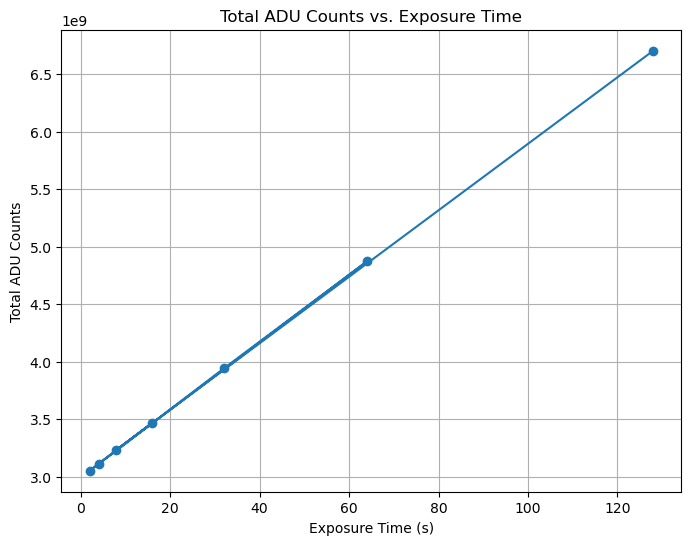

In [8]:
plot_adu_vs_exp_time(img_files_lintest)

Nice!!! That looks pretty linear to me! I think we're good, even all the way up to the 16-bit limit of the A-D converter! YAY!!

Moving on!!

-----

# Problem 2:

"Use photutils to perform aperture photometry on three (non saturated) stars in the PG1633+099 standard field: a really faint one, a medium bright one, and a bright one. Perform aperture photometry using at least 5 aperture sizes from very small to very large and make a plot that reproduces the one from Howell Figure 5.7 showing S/N as a function of aperture radius. What is a good aperture size to use for this dataset?"

Okay! The procedure for this will be as follows:
- Do all of the corrections (overscan subtraction/trimming, dark correction, etc)
- Perform the aperture photometry using photutils to find our three stars
- Reproduce the plot fromm Howell (figure 5.7) that shows S/N as a f'n of aperture radius
- Write out the aperture size we want.

First thing's first, I'm going to write out a function for making my otzb file. Here we go!!

In [98]:
from astropy.modeling.models import Polynomial1D
from astropy import units as u

def open_image(image_location):
    ccd = CCDData.read(image_location, format='fits', unit='adu') 
    return ccd
    
def process_image(ccd):
    data_ot = trim_image(ccd, fits_section='[54:2100,1:2048]')
    return data_ot

def subtract_and_trim(ccd):
    overscan = CCDData(np.concatenate((ccd.data[:, :53], ccd.data[:, 2101:]), axis=1), unit=ccd.unit)
    data_o = subtract_overscan(ccd, overscan=overscan, overscan_axis=1, model=Polynomial1D(degree=3))
    data_ot = process_image(data_o)
    return data_ot

def make_master_bias(bias_files):
    bias_images = [open_image(file) for file in bias_files]
    trimmed_bias_images = [subtract_and_trim(bias) for bias in bias_images]
    master_bias = combine(trimmed_bias_images, method='median', sigma_clip=True, sigma_clip_low_thresh=3, sigma_clip_high_thresh=3)
    return master_bias

def make_master_flat(flat_files, master_bias):
    flat_images = [open_image(file) for file in flat_files]
    trimmed_flat_images = [subtract_and_trim(flat) for flat in flat_images]
    bias_subtracted_flats = [flat.subtract(master_bias) for flat in trimmed_flat_images]
    master_flat = combine(bias_subtracted_flats, method='average', sigma_clip=True, sigma_clip_low_thresh=2, sigma_clip_high_thresh=2)
    science_data = master_flat.data
    median_val = np.nanmedian(science_data[science_data > 0])
    if median_val == 0:
        raise ValueError("Master flat has zero median - invalid flat field")
    master_flat = master_flat / median_val
    return master_flat

def make_master_dark(dark_files, master_bias):
    dark_images = [open_image(file) for file in dark_files]
    trimmed_dark_images = [subtract_and_trim(dark).subtract(master_bias) for dark in dark_images]
    bias_subtracted_darks = [flat.subtract(master_bias) for flat in trimmed_dark_images]
    master_dark = combine(bias_subtracted_darks, method='average', sigma_clip=True, sigma_clip_low_thresh=3, sigma_clip_high_thresh=3)
    return master_dark

def final_calibrated_image(image_location, master_bias, master_dark, master_flat):
    target_image = subtract_and_trim(open_image(image_location))
    bias_subtracted = target_image.subtract(master_bias)
    dark_subtracted = bias_subtracted.subtract(master_dark)
    if np.any(master_flat.data == 0):
        mask = master_flat.data == 0
        master_flat.data[mask] = np.nan
    calibrated_data = dark_subtracted.divide(master_flat)
    calibrated_data.unit = target_image.unit
    return calibrated_data


In [99]:
# Getting the bias files for the master calibration frames
bias_files = glob.glob(data_dir + 'a09[3-9]*.fits') + glob.glob(data_dir + 'a10[0-9]*.fits') + glob.glob(data_dir + 'a11[0-1]*.fits')

# Now for the flat files!
U_flat_files = glob.glob(data_dir + 'a02[1-8]*.fits')
B_flat_files = glob.glob(data_dir + 'a029.fits') + glob.glob(data_dir + 'a03[1-9]*.fits') + glob.glob(data_dir + 'a04[1-2]*.fits')
V_flat_files = glob.glob(data_dir + 'a04[3-9]*.fits') 
R_flat_files = glob.glob(data_dir + 'a05[0-5]*.fits')
I_flat_files = glob.glob(data_dir + 'a05[6-9]*.fits') + glob.glob(data_dir + 'a06[0-2]*.fits')

# Finally, the darks!
dark_files = glob.glob(data_dir + 'd0[1-9]*.fits') + glob.glob(data_dir + 'd1[0-5]*.fits')

In [120]:
# Getting the PG1633+099 files
pg1633_099_U_16sec = glob.glob(data_dir + 'a081.fits')[0] # THis is the Landolt Standard Field
pg1633_099_U_60sec = glob.glob(data_dir + 'a082.fits')[0]
pg1633_099_B_30sec = glob.glob(data_dir + 'a08[3-4]*.fits')[0]
pg1633_099_V_20sec = glob.glob(data_dir + 'a085.fits')[0]
pg1633_099_V_10sec = glob.glob(data_dir + 'a086.fits')[0]
pg1633_099_R_10sec = glob.glob(data_dir + 'a08[7-8]*.fits')[0]
pg1633_099_I_10sec = glob.glob(data_dir + 'a089.fits')[0] + glob.glob(data_dir + 'a090.fits')[0]

# Running the methods to make the master calibration frames
master_bias = make_master_bias(bias_files)
master_flat_U = make_master_flat(U_flat_files, master_bias)
master_dark = make_master_dark(dark_files, master_bias)

# Master calibration frame vs non-calibrated fram!
ot_landolt = subtract_and_trim(open_image(pg1633_099_U_16sec))
otzb_landolt = final_calibrated_image(pg1633_099_U_16sec, master_bias, master_dark, master_flat_U)

-23.37869049125743 49.50145260928151


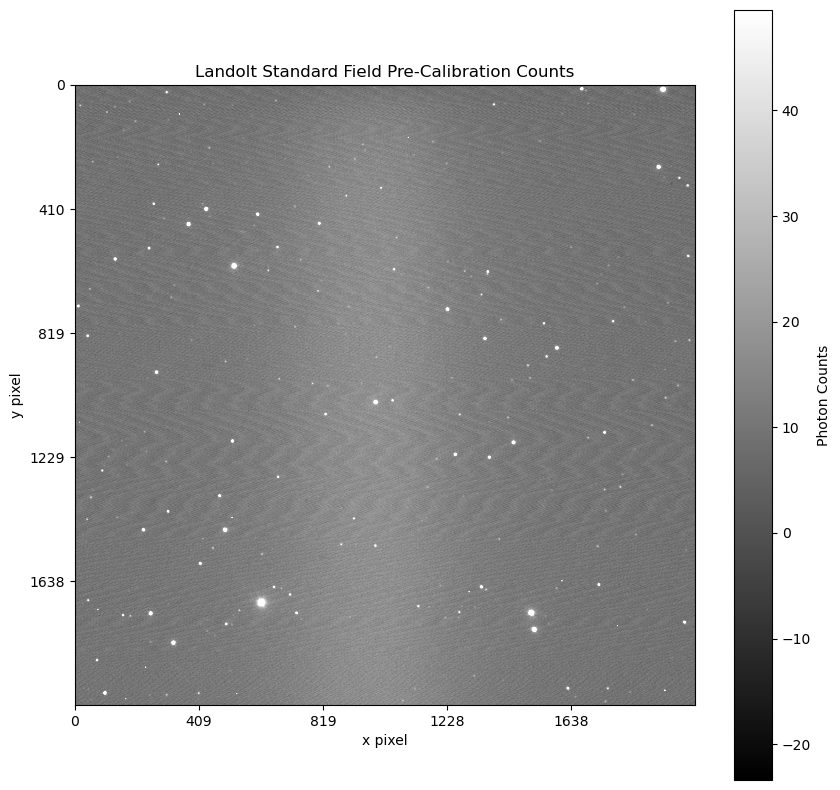

-29.559091606036553 54.09504389947226


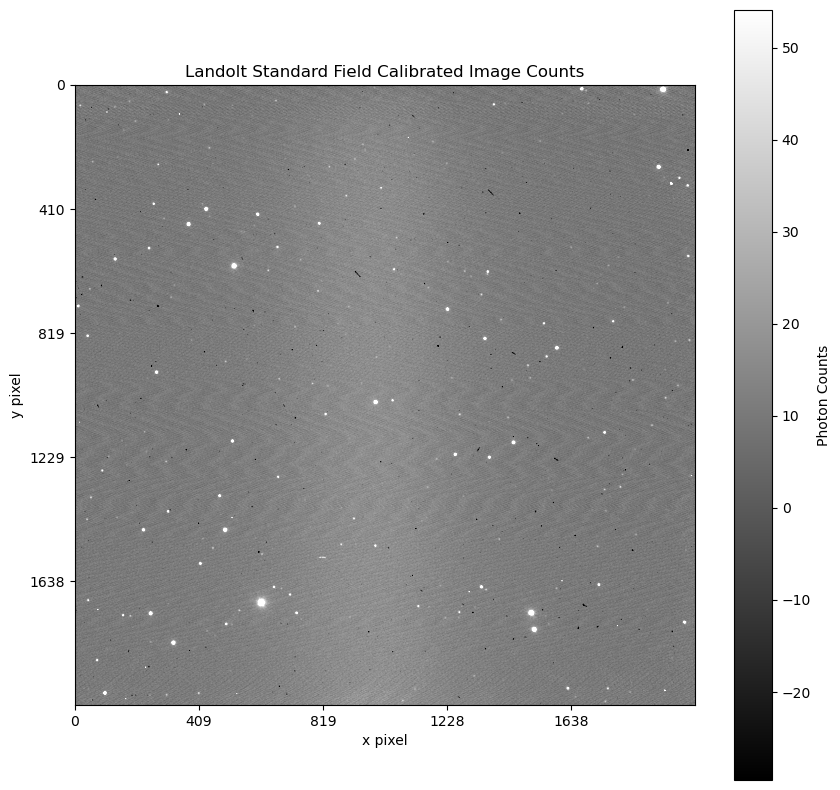

In [121]:
def plot_processed_file(file, plot_size, filename):
        
    interval = ZScaleInterval() 
    vmin, vmax = interval.get_limits(file) 
    print(vmin, vmax)
    width, height = plot_size
    ydim, xdim = file.shape

    fig = plt.subplots(1,1,figsize=(width, height))
    plt.imshow(file, vmin=vmin, vmax=vmax, cmap='gray')
    plt.xticks(np.arange(0, xdim, step=xdim/5)) 
    plt.yticks(np.arange(0, ydim, step=ydim/5)) 
    plt.xlabel('x pixel')
    plt.ylabel('y pixel')
    plt.title(f'{filename} Counts')
    plt.colorbar(label='Photon Counts')
    plt.grid(False)

    plt.show()

plot_processed_file(ot_landolt, (10, 10), "Landolt Standard Field Pre-Calibration")

plot_processed_file(otzb_landolt, (10, 10), "Landolt Standard Field Calibrated Image")

Gorgeous!!!!! Okay!!! Now, let's try to get the apparatus for finding the stars, finding the three different stars, as well as using all the different aperture size. From my snooping around on SAO, I am choosing the following stars:

In [135]:
x1 = 1044.35 - 53.0 # medium
x2 = 666.0 - 53.0 # bright
x3 = 1322.0 - 53.0 # faint
y1 = 2048.0 - 1049.0
y2 = 2048.0 - 1713.0
y3 = 2048.0 - 1088.0
positions = [(x1,y1),(x2,y2),(x3,y3)]

Here is a phot of them:

In [137]:
from photutils.aperture import CircularAperture, CircularAnnulus
from photutils.aperture import aperture_photometry
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from astropy.visualization import ImageNormalize, SqrtStretch

def plot_apertures(img, positions, filename, radius=5):

    # Prep
    interval = ZScaleInterval() 
    vmin, vmax = interval.get_limits(img) 
    ydim, xdim = img.shape 
    oriented_img = np.flip(np.rot90(img, k=2), 1)

    # Plotting
    fig = plt.subplots(1,1,figsize=(8,8))
    plt.imshow(oriented_img, vmin=vmin, vmax=vmax, cmap='gray') 
    plt.xticks(np.arange(0, xdim, step=500)) 
    plt.yticks(np.arange(0, ydim, step=500)) 
    plt.xlabel('x pixel')
    plt.ylabel('y pixel')
    plt.title(f'{filename}')
    plt.colorbar(label='Photon Counts')
    plt.grid(False)

    # Annulus patches
    aperture = CircularAperture(positions, r=radius)
    annulus_aperture = CircularAnnulus(positions, r_in=radius, r_out=radius+2)
    ap_patches = aperture.plot(color='white', lw=2, label='Photometry aperture')
    ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')

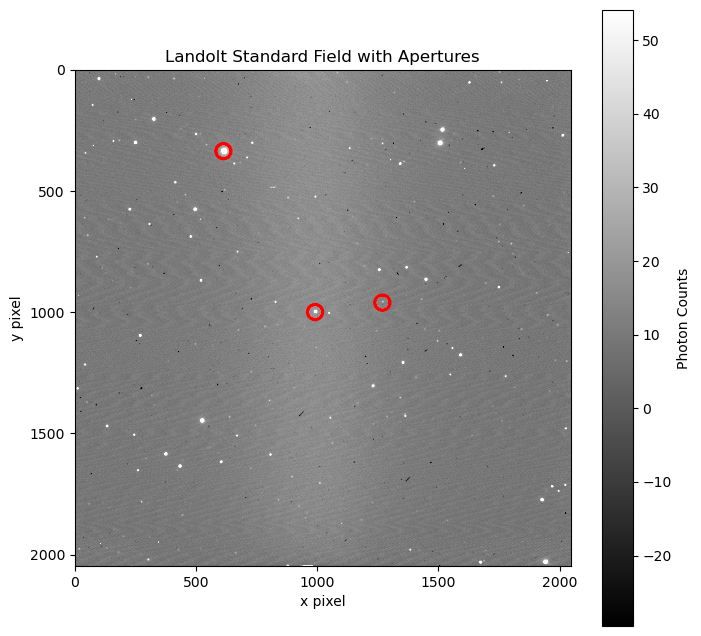

In [138]:
plot_apertures(otzb_landolt, positions, "Landolt Standard Field with Apertures", radius=30)

Nice! A cute family photo :)

Now, I am going to make a function that makes the SNR plot like Howell Figure 5.7. Wish me luck!

In [162]:
from photutils.aperture import ApertureStats

def aperture_photometry_test(file, aperture_radii):
    
    SNR_values = []

    for radius in aperture_radii:

        oriented_img = np.flip(np.rot90(file, k=2), 1) 
        aperture = CircularAperture(positions, r=radius)
        annulus_aperture = CircularAnnulus(positions, r_in=radius*2, r_out=radius*3)
        aperstats = ApertureStats(oriented_img, annulus_aperture)
        bkg_mean = aperstats.mean
        phot_table = aperture_photometry(oriented_img, aperture)
        SNR_values.append((phot_table['aperture_sum'] - bkg_mean * aperture.area) / np.sqrt(phot_table['aperture_sum'] + bkg_mean * aperture.area))
    
    fig = plt.subplots(1,1,figsize=(8, 8))
    plt.plot(aperture_radii, SNR_values, marker='o')
    plt.xlabel('Aperture Radius (pixels)')
    plt.ylabel('SNR')
    plt.title('Landolt Standard Graph')
    plt.grid(False)


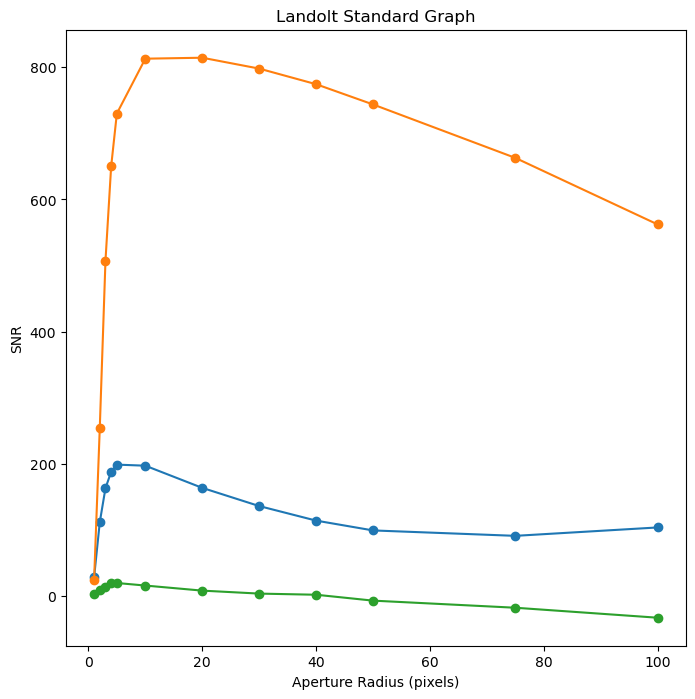

In [163]:
aperture_photometry_test(otzb_landolt, aperture_radii=[1, 2, 3, 4, 5, 10, 20, 30, 40, 50, 75, 100])

Wonderful!!! That looks like a faithful recreation, if you ask me!!

it seems like the optimal aperture radius is hovering around 10-20 pixels. Here's the fine grained approach to see what's up:

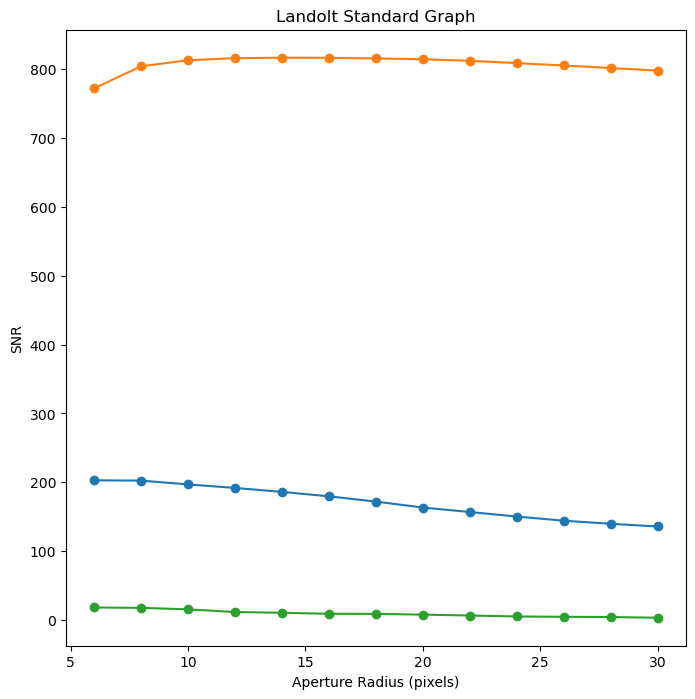

In [164]:
aperture_photometry_test(otzb_landolt, aperture_radii=[6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30])

The best bang for one's buck seems to happen around 10 pixels. Noted and moving on!!!

-----

# Problem 3:

"Identify the standard stars in the PG1633+099 frame from Landolt (1992)."


Okay!! From the paper (https://articles.adsabs.harvard.edu/pdf/1992AJ....104..340L), we have a HUUUUUUGE table of things to sort through. Here's my initial thought: let's check the header for information on positions:

In [156]:
star_identity_start = CCDData.read(pg1633_099_U_16sec, unit='adu', format='fits') 
star_identity_start.header.keys

<bound method Header.keys of SIMPLE  =                    T / Fits standard                                  
BITPIX  =                   16 / Bits per pixel                                 
NAXIS   =                    2 / Number of axes                                 
NAXIS1  =                 2200 / Axis length                                    
NAXIS2  =                 2048 / Axis length                                    
EXTEND  =                    F / File may contain extensions                    
BSCALE  =           1.000000E0 / REAL = TAPE*BSCALE + BZERO                     
BZERO   =           3.276800E4 /                                                
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
DATE    = '2009-09-15T15:56:29' / Date FITS file was generated                  
IRAF-TLM= '09:56:29 (15/09/2009)' / Time of last modification                   
DATAMIN =           0.000000E0 / Minimum data value                             

Ah! I looked forther down in the paper, and found the exact stars we want to identify! Wonderful!

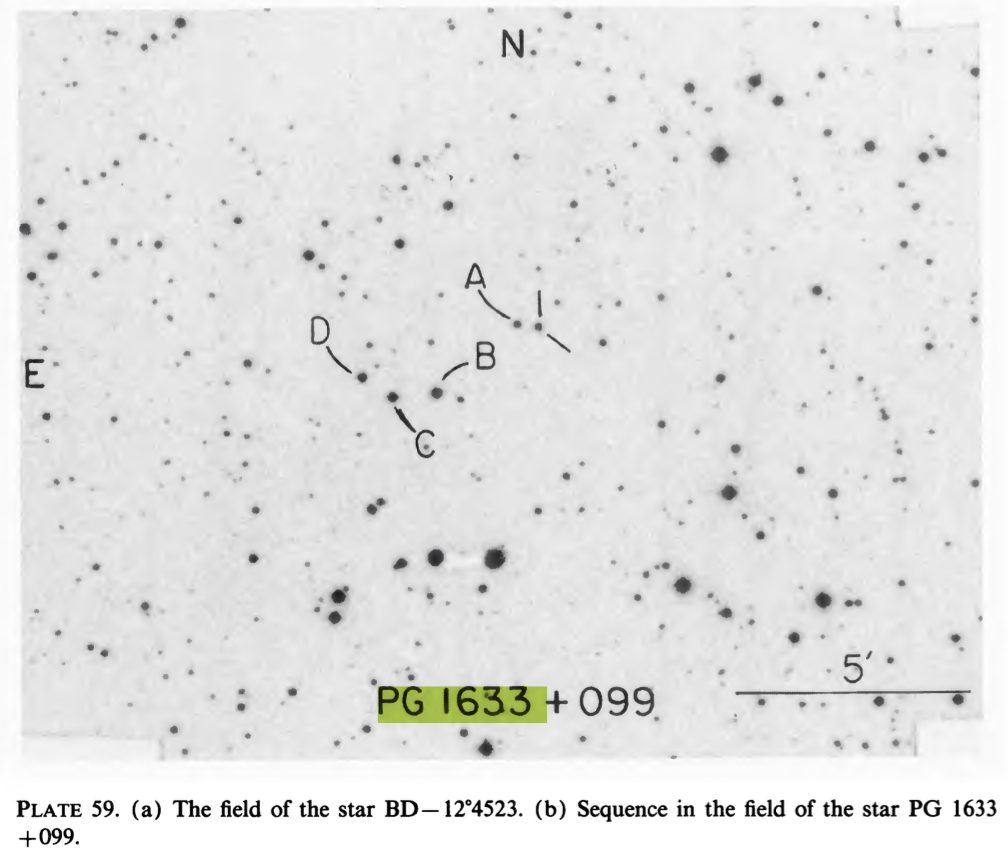

In [158]:
from IPython.display import Image
Image(filename='landoltstandard.png', width=800)

I'm going to find the locations of these stars in SAO, and then plot them for you!

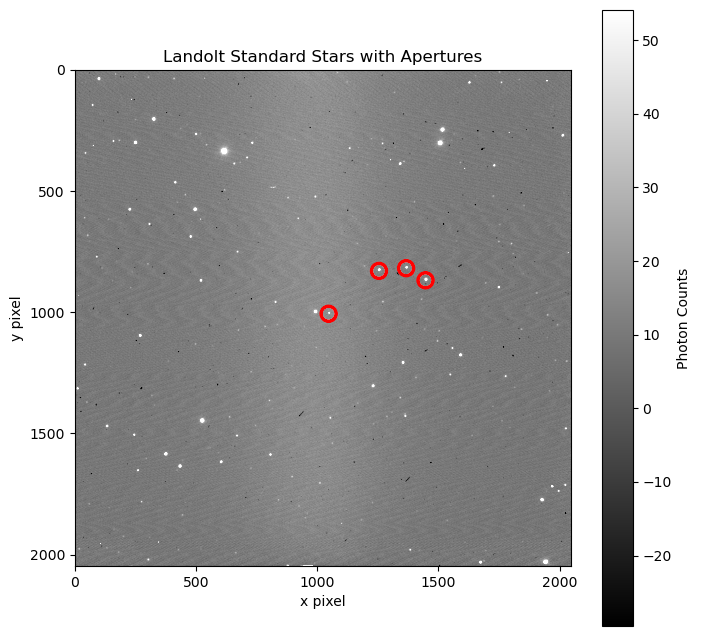

In [161]:
xA = 1100.0 - 53.0 
xB = 1308.0 - 53.0 
xC = 1420.0 - 53.0 
xD = 1500.0 - 53.0 
yA = 2048.0 - 1042.0
yB = 2048.0 - 1219.0
yC = 2048.0 - 1230.0
yD = 2048.0 - 1180.0

landolt_positions = [(xA,yA),(xB,yB),(xC,yC),(xD,yD)]
plot_apertures(otzb_landolt, landolt_positions, "Landolt Standard Stars with Apertures", radius=30)

TA-DAAAAAA!!!!

-----

# Problem 4:

"Extract instrumental magnitudes for all of your standard stars using an approach that you’ve advocated for as best you can in the questions above."

Okay. The procedure for this is outlined in the apertures.ipynb notebook. I didn't finish it in time, so we're going to try our best here and now. 

The approach is to calculate the aperture photometry counts in each of these annuli (choosing 10 counts for this exercise from my above Landolt SNR comparison graph)

In [180]:
def calculate_aperture_stats(img, positions, radius=10):

    # Flipping image back around
    oriented_img = np.flip(np.rot90(img, k=2), 1) 

    # Setting up the apertures
    aperture = CircularAperture(positions, r=radius)
    annulus_aperture = CircularAnnulus(positions, r_in=radius*2, r_out=radius*3)

    # Getting the aperstats
    aperstats = ApertureStats(oriented_img, annulus_aperture)
    bkg_mean = aperstats.mean

    # Extracting the sum!!
    phot_table = aperture_photometry(oriented_img, aperture)
    for col in phot_table.colnames:
        phot_table[col].info.format = '%.8g'  # for consistent table output

    # What are the areas of the apertures?
    area_total = aperture.area

    # Finding the background counts
    phot_table['background_counts'] = bkg_mean *  area_total
    phot_table['background_subtracted_sum'] = phot_table['aperture_sum'] - phot_table['background_counts']

    # Last but not least, finding the instrumental magnitude!! 
    # m = -2.5*log(S)=-2.5*log(T-AB)
    phot_table['instrumental_mag'] = -2.5 * np.log10(phot_table['background_subtracted_sum'])

    # Return
    return bkg_mean, phot_table, area_total

In [181]:
calculate_aperture_stats(otzb_landolt, landolt_positions, radius=10)

(array([16.85404001, 13.29699483, 11.79710293, 11.12833022]),
 <QTable length=4>
   id  xcenter ycenter ... background_subtracted_sum instrumental_mag
         pix     pix   ...                                           
 int64 float64 float64 ...          float64              float64     
 ----- ------- ------- ... ------------------------- ----------------
     1    1047    1006 ...                  2846.635       -8.6358295
     2    1255     829 ...                 12079.337       -10.205108
     3    1367     818 ...                 8630.2993       -9.8400646
     4    1447     868 ...                  24441.67       -10.970327,
 314.1592653589793)

Wonderful!

-----

# Problem 5:

"Plot your standard star instrumental magnitudes versus their airmass (or since you have many different standard stars taken at different airmass, plot the difference between the accepted magnitude and your instrumental magnitude versus airmass). Use one of the linear fitting routines in Python to do a least squares fit to find and plot the extinction coefficients at each filter. You can find their magnitudes and colors in Landolt (1992)."

Cool!!! Here's the full text for the PG1633+099 sample:

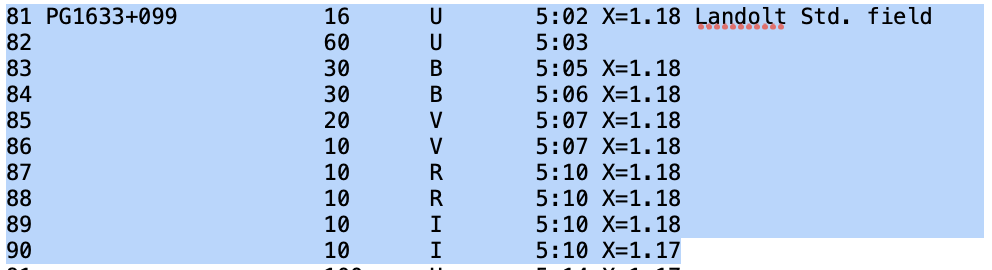

In [170]:
Image(filename='pg1633files.png', width=800)

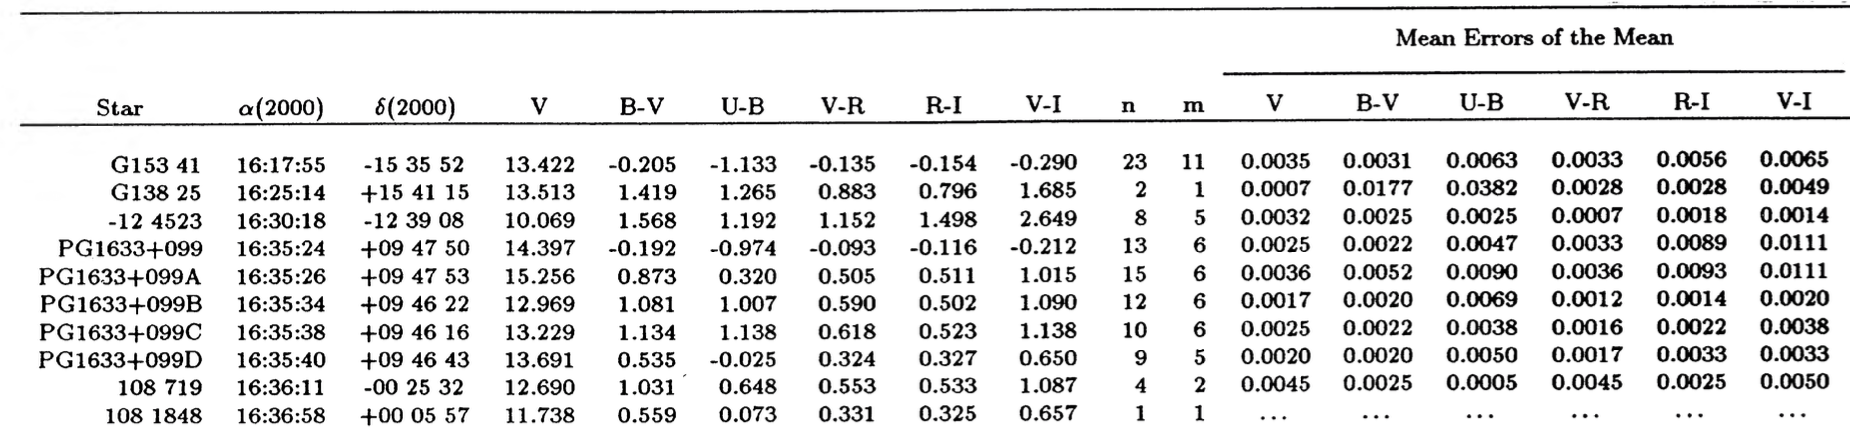

In [173]:
Image(filename='pg1633chart.png', width=1200)

Okay, so THIS is gonna be an intriguing challenge... hmmmm

Just for the record, I got the following U magnitudes:
- A = 8.64
- B = 10.21
- C = 9.84
- D = 10.97

What to do now?... let's try the other magnitudes? Why not?

First, let's calculate the magnitudes for each of the stars and put them in a little table:

In [188]:
import pandas as pd

objects_data = {'Object': ['Star A', 'Star B', 'Star C', 'Star D'],
        'V': [15.256, 12.969, 13.229, 13.691],
        'B': [0.873 + 15.256, 1.081 + 12.969, 1.134 + 13.229, 0.535 + 13.691],
        'U': [0.320 + 0.873 + 15.256, 1.007 + 1.081 + 12.969, 1.138 + 1.134 + 13.229, -0.025 + 0.535 + 13.691],
        'R': [15.256 - 0.505, 12.969 - 0.590, 13.229 - 0.618, 13.691 - 0.324],
        'I': [15.256 - 1.015, 12.969 - 1.090, 13.229 - 1.138, 13.691 - 0.650]}

Okay. Now, let's make the big chart of comparisons for our records. THis'll be a lot, so buckle in!

In [ ]:
def calculate_full_calibrated_aperture_stats(image_locations, positions, band_flat_files, airmass, radius=10):

    phot_table = None

    for image_location in image_locations:
        # Open and calibrate the image
        master_bias = make_master_bias(bias_files)
        master_flat = make_master_flat(band_flat_files, master_bias)
        master_dark = make_master_dark(dark_files, master_bias)
        calibrated_img = final_calibrated_image(image_location, master_bias, master_dark, master_flat)

        # Calculate the aperture stats on the calibrated image
        _, phot_table_vals, _ = calculate_aperture_stats(calibrated_img, positions, radius)

        # Append the resulting magnitude (flipped minus sign) to the phot_table
        if phot_table is None:
            phot_table = phot_table_vals
            phot_table['instrumental_mag_X' + str(airmass)] = -phot_table['instrumental_mag']
        else:
            phot_table['instrumental_mag_X' + str(airmass)] = np.append(phot_table['instrumental_mag_X' + str(airmass)], -phot_table_vals['instrumental_mag'])

    
    return phot_table

In [ ]:
# Getting the PG1633+099 files (first run)
pg1633_099_U_16sec_X118 = glob.glob(data_dir + 'a081.fits')
pg1633_099_U_60sec_X118 = glob.glob(data_dir + 'a082.fits')
pg1633_099_B_30sec_X118_1 = glob.glob(data_dir + 'a083.fits')
pg1633_099_B_30sec_X118_2 = glob.glob(data_dir + 'a084.fits')
pg1633_099_V_20sec_X118 = glob.glob(data_dir + 'a085.fits')
pg1633_099_V_10sec_X118 = glob.glob(data_dir + 'a086.fits')
pg1633_099_R_10sec_X118_1 = glob.glob(data_dir + 'a087.fits')
pg1633_099_R_10sec_X118_2 = glob.glob(data_dir + 'a088.fits')
pg1633_099_I_10sec_X118 = glob.glob(data_dir + 'a089.fits') 
pg1633_099_I_10sec_X117 = glob.glob(data_dir + 'a090.fits')

# (Second run)
pg1633_099_U_60sec_X123 = glob.glob(data_dir + 'a130.fits')
pg1633_099_U_60sec_X124 = glob.glob(data_dir + 'a131.fits')
pg1633_099_B_30sec_X124_1 = glob.glob(data_dir + 'a132.fits')
pg1633_099_B_30sec_X124_2 = glob.glob(data_dir + 'a133.fits')
pg1633_099_V_10sec_X124_1 = glob.glob(data_dir + 'a134.fits')
pg1633_099_V_10sec_X124_2 = glob.glob(data_dir + 'a135.fits')
pg1633_099_R_10sec_X124_1 = glob.glob(data_dir + 'a136.fits')
pg1633_099_R_10sec_X124_2 = glob.glob(data_dir + 'a137.fits')
pg1633_099_I_10sec_X124_1 = glob.glob(data_dir + 'a138.fits')
pg1633_099_I_10sec_X124_2 = glob.glob(data_dir + 'a139.fits')

# Third run
pg1633_099_U_60sec_X149_1 = glob.glob(data_dir + 'a202.fits')
pg1633_099_U_60sec_X149_2 = glob.glob(data_dir + 'a203.fits')
pg1633_099_B_30sec_X151_1 = glob.glob(data_dir + 'a204.fits')
pg1633_099_B_30sec_X151_2 = glob.glob(data_dir + 'a205.fits')
pg1633_099_V_10sec_X152_1 = glob.glob(data_dir + 'a206.fits')
pg1633_099_V_10sec_X152_2 = glob.glob(data_dir + 'a207.fits')
pg1633_099_R_10sec_X153_1 = glob.glob(data_dir + 'a208.fits')
pg1633_099_R_10sec_X153_2 = glob.glob(data_dir + 'a209.fits')
pg1633_099_I_10sec_X153_1 = glob.glob(data_dir + 'a210.fits')
pg1633_099_I_10sec_X153_2 = glob.glob(data_dir + 'a211.fits')

# Fourth run
pg1633_099_U_60sec_X204_1 = glob.glob(data_dir + 'a221.fits')
pg1633_099_U_60sec_X204_2 = glob.glob(data_dir + 'a222.fits')
pg1633_099_B_30sec_X206_1 = glob.glob(data_dir + 'a223.fits')
pg1633_099_B_30sec_X206_2 = glob.glob(data_dir + 'a224.fits')
pg1633_099_B_20sec_X208_1 = glob.glob(data_dir + 'a225.fits')
pg1633_099_B_20sec_X208_2 = glob.glob(data_dir + 'a226.fits')
pg1633_099_V_8sec_X210_1 = glob.glob(data_dir + 'a227.fits')
pg1633_099_V_8sec_X210_2 = glob.glob(data_dir + 'a228.fits')
pg1633_099_V_5sec_X210_1 = glob.glob(data_dir + 'a229.fits')
pg1633_099_V_5sec_X210_2 = glob.glob(data_dir + 'a230.fits')
pg1633_099_R_5sec_X211_1 = glob.glob(data_dir + 'a231.fits')
pg1633_099_R_5sec_X211_2 = glob.glob(data_dir + 'a232.fits')
pg1633_099_I_5sec_X212_1 = glob.glob(data_dir + 'a233.fits')
pg1633_099_I_5sec_X212_2 = glob.glob(data_dir + 'a234.fits')
pg1633_099_R_3sec_X212_1 = glob.glob(data_dir + 'a235.fits')
pg1633_099_R_3sec_X212_2 = glob.glob(data_dir + 'a236.fits')

# Fifth run
pg1633_099_U_60sec_X215_1 = glob.glob(data_dir + 'a237.fits')
pg1633_099_U_60sec_X215_2 = glob.glob(data_dir + 'a238.fits')
pg1633_099_B_30sec_X219_1 = glob.glob(data_dir + 'a239.fits')
pg1633_099_B_30sec_X219_2 = glob.glob(data_dir + 'a240.fits')
pg1633_099_V_10sec_X221_1 = glob.glob(data_dir + 'a241.fits')
pg1633_099_V_10sec_X221_2 = glob.glob(data_dir + 'a242.fits')
pg1633_099_R_10sec_X223_1 = glob.glob(data_dir + 'a243.fits')
pg1633_099_R_10sec_X223_2 = glob.glob(data_dir + 'a244.fits')
pg1633_099_I_10sec_X226_1 = glob.glob(data_dir + 'a245.fits')
pg1633_099_I_10sec_X226_2 = glob.glob(data_dir + 'a246.fits')


# Combining them all!
u_X118 = [pg1633_099_U_16sec_X118, pg1633_099_U_60sec_X118]
b_X118 = [pg1633_099_B_30sec_X118_1, pg1633_099_B_30sec_X118_2]
v_X118 = [pg1633_099_V_20sec_X118, pg1633_099_V_10sec_X118]
r_X118 = [pg1633_099_R_10sec_X118_1, pg1633_099_R_10sec_X118_2]
i_X118 = [pg1633_099_I_10sec_X118]
i_X117 = [pg1633_099_I_10sec_X117]

u_X123 = [pg1633_099_U_60sec_X123]
u_X124 = [pg1633_099_U_60sec_X124]
b_X124 = [pg1633_099_B_30sec_X124_1, pg1633_099_B_30sec_X124_2]
v_X124 = [pg1633_099_V_10sec_X124_1, pg1633_099_V_10sec_X124_2]
r_X124 = [pg1633_099_R_10sec_X124_1, pg1633_099_R_10sec_X124_2]
i_X124 = [pg1633_099_I_10sec_X124_1, pg1633_099_I_10sec_X124_2]

u_X149 = [pg1633_099_U_60sec_X149_1, pg1633_099_U_60sec_X149_2]
b_X151 = [pg1633_099_B_30sec_X151_1, pg1633_099_B_30sec_X151_2]
v_X152 = [pg1633_099_V_10sec_X152_1, pg1633_099_V_10sec_X152_2]
r_X153 = [pg1633_099_R_10sec_X153_1, pg1633_099_R_10sec_X153_2]
i_X153 = [pg1633_099_I_10sec_X153_1, pg1633_099_I_10sec_X153_2]

u_X204 = [pg1633_099_U_60sec_X204_1, pg1633_099_U_60sec_X204_2]
b_X206 = [pg1633_099_B_30sec_X206_1, pg1633_099_B_30sec_X206_2]
b_X208 = [pg1633_099_B_20sec_X208_1, pg1633_099_B_20sec_X208_2]
v_X210 = [pg1633_099_V_8sec_X210_1, pg1633_099_V_8sec_X210_2, pg1633_099_V_5sec_X210_1, pg1633_099_V_5sec_X210_2]
r_X211 = [pg1633_099_R_5sec_X211_1, pg1633_099_R_5sec_X211_2, pg1633_099_R_3sec_X212_1, pg1633_099_R_3sec_X212_2]
i_X212 = [pg1633_099_I_5sec_X212_1, pg1633_099_I_5sec_X212_2]

That was exhausting! Holy shit! Okay, let's try our aperture photometry techniques on this.

-----

# Problem 6:

"After extinction correcting your standard stars to zero airmasses (i.e., you’re correcting to the top of the atmosphere), make a plot of the difference between real magnitudes and instrumental magnitudes using your standard stars as a function of V−R color and B−V color. Fit a linear relation to this trend. The fit gives you your instrumental zero points and the first order color term which let you transform your instrumental photometry to the standard system. Tabulate the instrumental zero point and first order color terms for each band in a neat, digestible way."

-----

# Problem 7:

"Using the extinction terms and color terms derived for the imaging dataset previously, do photometry on the stars in NGC6823 and make a color magnitude diagram of this open cluster. Either V vs. B−V or R vs. R−I are the most common ones you might find, but there may be others in the literature and you are welcome to follow their lead."

Lastly, let's do NGC6823!